In [8]:
!pip install jax jaxlib matplotlib

In [9]:
import jax
import jax.numpy as jnp
import numpy as np
import time
import matplotlib.pyplot as plt


In [10]:
def heavy_function(x):
    x = jnp.sin(x)
    x = jnp.cos(x)
    x = jnp.exp(x)
    x = jnp.log(x + 1)
    x = jnp.square(x)
    x = jnp.sin(x)
    x = jnp.cos(x)
    x = jnp.exp(x)
    x = jnp.sqrt(x)
    x = jnp.tanh(x)
    return x

In [11]:
jit_function = jax.jit(heavy_function)


In [12]:
def measure_times(size):

    x = jnp.ones((size, size))

    # eager
    start = time.time()
    heavy_function(x).block_until_ready()
    eager_time = time.time() - start

    # first jit
    start = time.time()
    jit_function(x).block_until_ready()
    first_jit = time.time() - start

    # second jit
    start = time.time()
    jit_function(x).block_until_ready()
    second_jit = time.time() - start

    return eager_time, first_jit, second_jit


In [13]:
sizes = [100, 500, 1000, 5000]

eager_times = []
first_jit_times = []
second_jit_times = []

for s in sizes:
    e, j1, j2 = measure_times(s)
    eager_times.append(e)
    first_jit_times.append(j1)
    second_jit_times.append(j2)

print("Done")


Done


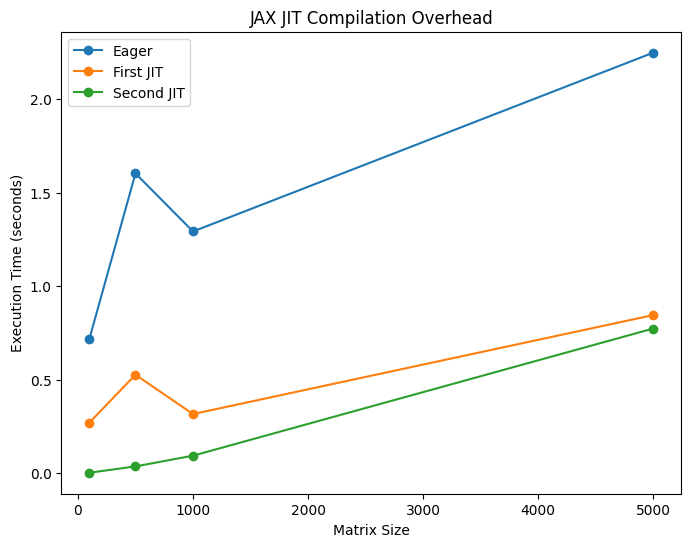

In [14]:
plt.figure(figsize=(8,6))

plt.plot(sizes, eager_times, marker='o', label="Eager")
plt.plot(sizes, first_jit_times, marker='o', label="First JIT")
plt.plot(sizes, second_jit_times, marker='o', label="Second JIT")

plt.xlabel("Matrix Size")
plt.ylabel("Execution Time (seconds)")
plt.title("JAX JIT Compilation Overhead")
plt.legend()

plt.show()


In [15]:
@jax.jit
def row_mean(x):
    return jnp.mean(x, axis=1)


[0.0003197193145751953, 0.00010728836059570312, 9.202957153320312e-05, 0.00028395652770996094]


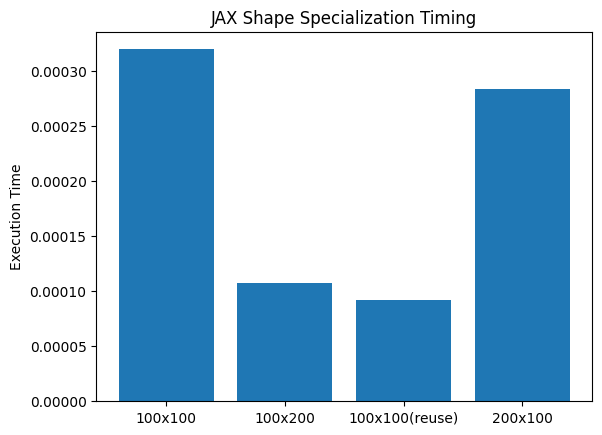

In [21]:
inputs = [
    jnp.ones((100,100)),
    jnp.ones((100,200)),
    jnp.ones((100,100)),
    jnp.ones((200,100))
]
times = []

for x in inputs:
    start = time.time()
    row_mean(x).block_until_ready()
    times.append(time.time() - start)

print(times)
labels = ["100x100","100x200","100x100(reuse)","200x100"]


plt.bar(labels, times)

plt.title("JAX Shape Specialization Timing")
plt.ylabel("Execution Time")

plt.show()


In [18]:
def version_a(x):

    result = 0

    for i in range(1,101):
        result += jnp.sin(x)**i + jnp.cos(x)**i

    return result


In [19]:
@jax.jit
def version_b(x):

    result = 0

    for i in range(1,101):
        result += jnp.sin(x)**i + jnp.cos(x)**i

    return result


In [20]:
x = jnp.ones((1000,1000))

start = time.time()
version_a(x).block_until_ready()
time_a = time.time() - start

start = time.time()
version_b(x).block_until_ready()
time_b = time.time() - start

print("Version A:", time_a)
print("Version B:", time_b)


Version A: 7.040592670440674
Version B: 0.5249457359313965
